## Concatenating all place_id files

The following script reads through the separate collected place Twitter API responses for the three cities, and converts them to a valid JSON using sed commands (see `utils/json_converter.sh`). If after the conversion `jq` still cannot parse the JSON, the result is saved into `places_w_error.json`. Otherwise, valid JSON objects are saved per line into `places.json` for all three cities (`amsterdam`, `portland`, `Greater-London`).

In [ ]:
%%bash

# takes about 1 hour

: > places.json
: > places_w_error.json

# nonempty place_ids folders
# for the other cities, there were no files
for folder in `echo "/mnt/common-hdd/raw-sources/twitter-data/raw-data/place_ids /mnt/common-hdd/raw-sources/twitter-data/raw-data/amsterdam/place_ids"`
do
  echo $folder
  for f in `ls "$folder"`
  do
      if bash utils/place_json_filter.sh "$folder/$f" | jq -c . > /dev/null; then
      bash utils/place_json_filter.sh "$folder/$f" | jq -c . >> places.json 2> /dev/null
      else
      echo bash utils/place_json_filter.sh "$folder/$f" >> places_w_error.csv
      fi
  done
done

How many places were correctly parsed?

In [14]:
!cat places.json | wc -l

39531


How many places were incorrectly parsed??

In [ ]:
!cat places_w_error.csv | wc -l

531


Collecting the places with errors into a file.

In [ ]:
!:> places_w_error.json; for f in `cat places_w_error.csv | cut -d" " -f3`; do cat $f >> places_w_error.json; echo >>places_w_error.json; done

Asking ChatGPT to convert this to a normalized json, result is `places_w_error_corrected.json`, it was readable to `jq`, so all is fine. Concatenating this to `places.json`.

In [17]:
%%bash 

cat places.json places_w_error_corrected.json > places_all.json

Remove intermediate files.

In [ ]:
%%bash

rm places.json places_w_error.csv places_w_error.json places_w_error_corrected.json

## Building the place table for database insertion

In [ ]:
import json
import pandas as pd
import numpy as np
from haversine import haversine, Unit

Read all place JSONs into a dataframe.

In [10]:
with open('places_all.json') as f:
    df = pd.read_json(f, lines=True)
display(df.head())
print(df.shape)

,_api,id,name,full_name,country,country_code,url,place_type,attributes,bounding_box,centroid,contained_within,polylines,geometry,vendor_info,_type,withheld
0,tweepy.api.API object at 0x000001E1A736ACE0,0000c53267c193f9,Dacca,"Dacca, Bangladesh",Bangladesh,BD,https://api.twitter.com/1.1/geo/id/0000c53267c...,city,{},{'_api': 'tweepy.api.API object at 0x000001E1A...,"[90.41252838449833, 23.70270825]",[{'_api': 'tweepy.api.API object at 0x000001E1...,[],None,NaN,NaN,NaN
1,tweepy.api.API object at 0x000001E1AED26F20,0001ed7e605ce519,Bonney Lake,"Bonney Lake, WA",United States,US,https://api.twitter.com/1.1/geo/id/0001ed7e605...,city,{'geotagCount': '37'},{'_api': 'tweepy.api.API object at 0x000001E1A...,"[-122.17051473268205, 47.180536000000004]",[{'_api': 'tweepy.api.API object at 0x000001E1...,[],None,NaN,NaN,NaN
2,tweepy.api.API object at 0x000001E1A857E0E0,00066ad5394a937f,Varnavas,"Varnavas, Greece",Greece,GR,https://api.twitter.com/1.1/geo/id/00066ad5394...,city,{},{'_api': 'tweepy.api.API object at 0x000001E1A...,"[23.940654001703766, 38.246251]",[{'_api': 'tweepy.api.API object at 0x000001E1...,[],None,NaN,NaN,NaN
3,tweepy.api.API object at 0x000001E1AED26F20,000799c66e428a87,Jeddah,"Jeddah, Kingdom of Saudi Arabia",Kingdom of Saudi Arabia,SA,https://api.twitter.com/1.1/geo/id/000799c66e4...,city,{},{'_api': 'tweepy.api.API object at 0x000001E1A...,"[39.26493447078151, 21.585649099999998]",[{'_api': 'tweepy.api.API object at 0x000001E1...,[],None,NaN,NaN,NaN
4,tweepy.api.API object at 0x000001E19CCC8F70,000be298657c0412,West Haven,"West Haven, OR",United States,US,https://api.twitter.com/1.1/geo/id/000be298657...,city,{'geotagCount': '21'},{'_api': 'tweepy.api.API object at 0x000001E19...,"[-122.77212993552092, 45.517627000000005]",[{'_api': 'tweepy.api.API object at 0x000001E1...,[],None,NaN,NaN,NaN


(40062, 17)


There are 392 rows in which bounding box does not exist, place type is poi, and somehow the response was "Place name removed" etc. We drop these.

In [11]:
print("Number of empty bounding boxes:", df["bounding_box"].isnull().sum())
df = df[df["bounding_box"].notnull()].copy()
print("After dropping empty bounding boxes:", df.shape)

Number of empty bounding boxes: 392
After dropping empty bounding boxes: (39670, 17)


Drop duplicates.

In [12]:
df.drop_duplicates(subset=['id'], inplace=True)
print("After dropping duplicates:", df.shape)

After dropping duplicates: (34097, 17)


Extracting bounding box and centroid coordinates.

In [13]:
df["lat_min"] = df['bounding_box'].map(lambda d: d["coordinates"][0][0][1])
df["lat_max"] = df['bounding_box'].map(lambda d: d["coordinates"][0][2][1])
df["lon_min"] = df['bounding_box'].map(lambda d: d["coordinates"][0][0][0])
df["lon_max"] = df['bounding_box'].map(lambda d: d["coordinates"][0][2][0])
df["centroid_lat"] = df['centroid'].map(lambda d: d[1])
df["centroid_lon"] = df['centroid'].map(lambda d: d[0])
df = df[["id","name","full_name","country_code","place_type","lon_min","lon_max","lat_min","lat_max","centroid_lon","centroid_lat"]].copy()
display(df.head())
print(df.shape)

,id,name,full_name,country_code,place_type,lon_min,lon_max,lat_min,lat_max,centroid_lon,centroid_lat
0,0000c53267c193f9,Dacca,"Dacca, Bangladesh",BD,city,90.372055,90.426804,23.683083,23.725916,90.412528,23.702708
1,0001ed7e605ce519,Bonney Lake,"Bonney Lake, WA",US,city,-122.214616,-122.117391,47.147327,47.214385,-122.170515,47.180536
2,00066ad5394a937f,Varnavas,"Varnavas, Greece",GR,city,23.901515,23.981961,38.204028,38.288459,23.940654,38.246251
3,000799c66e428a87,Jeddah,"Jeddah, Kingdom of Saudi Arabia",SA,city,38.929659,39.578598,20.913775,22.257646,39.264934,21.585649
4,000be298657c0412,West Haven,"West Haven, OR",US,city,-122.803240,-122.738106,45.505728,45.529576,-122.772130,45.517627


(34097, 11)


Calculating bounding box error - haversine distance of SW and NE corners of bounding box divided by 2.

In [16]:
df['err'] = df.apply(lambda row: haversine((row['lat_min'], row['lon_min']), (row['lat_max'], row['lon_max']), unit=Unit.METERS) / 2, axis=1)
df.head()

,id,name,full_name,country_code,place_type,lon_min,lon_max,lat_min,lat_max,centroid_lon,centroid_lat,err
0,0000c53267c193f9,Dacca,"Dacca, Bangladesh",BD,city,90.372055,90.426804,23.683083,23.725916,90.412528,23.702708,3665.919270
1,0001ed7e605ce519,Bonney Lake,"Bonney Lake, WA",US,city,-122.214616,-122.117391,47.147327,47.214385,-122.170515,47.180536,5234.345531
2,00066ad5394a937f,Varnavas,"Varnavas, Greece",GR,city,23.901515,23.981961,38.204028,38.288459,23.940654,38.246251,5862.844073
3,000799c66e428a87,Jeddah,"Jeddah, Kingdom of Saudi Arabia",SA,city,38.929659,39.578598,20.913775,22.257646,39.264934,21.585649,81901.988940
4,000be298657c0412,West Haven,"West Haven, OR",US,city,-122.803240,-122.738106,45.505728,45.529576,-122.772130,45.517627,2862.932500


Renaming columns and saving result.

In [17]:
df.rename(
    columns={
        "id": "place_id",
        "name": "place_name",
    },
    inplace=True
)


In [19]:
df.to_csv('../tables/place.csv', index=False, header=True)

## Some statistics

In [20]:
# distributin of place types
df['place_type'].value_counts()


poi             32211
neighborhood     1225
city              462
admin             121
country            78
Name: place_type, dtype: int64

[]

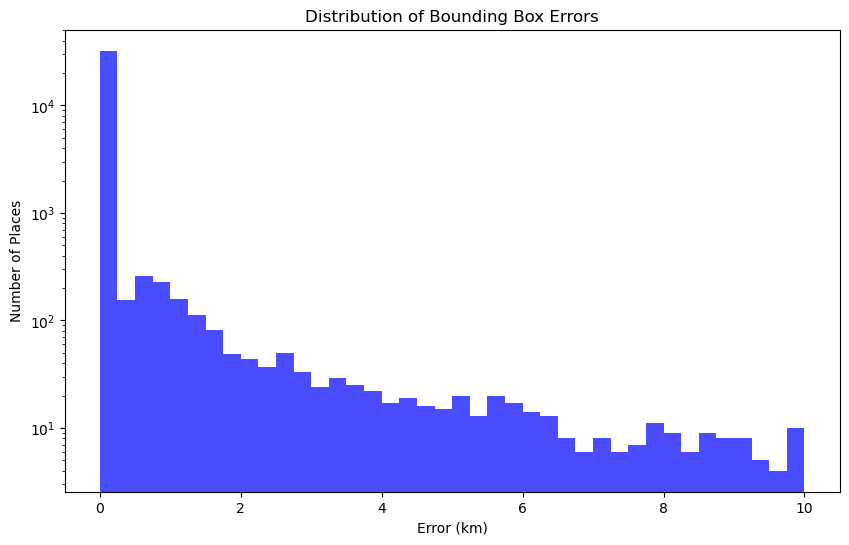

In [25]:
# plot distribution of errors within first 10 km
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.hist(df['err']/1000, bins=40, range=(0,10), color='blue', alpha=0.7)
plt.title('Distribution of Bounding Box Errors')
plt.xlabel('Error (km)')
plt.ylabel('Number of Places')
plt.semilogy()


In [27]:
# number of places with error < 1 km
(df['err'] < 500).sum()

32392

<AxesSubplot:>

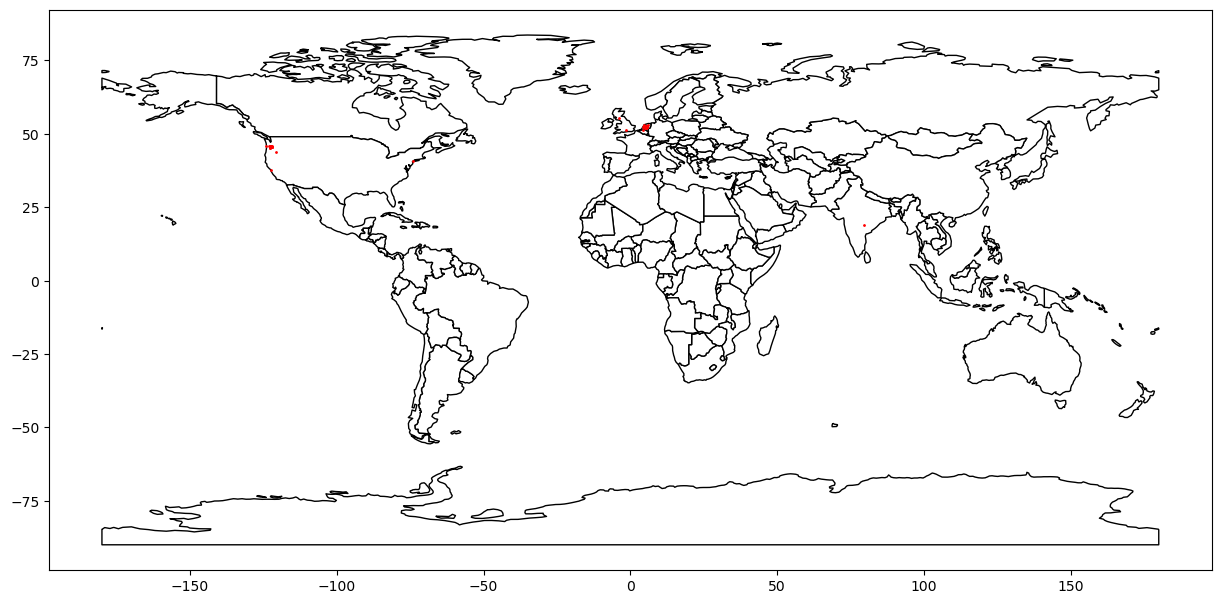

In [28]:
# plot a world map from the <500m error places
import geopandas as gpd
from shapely.geometry import Point
df_small_err = df[df['err'] < 500].copy()
geometry = [Point(xy) for xy in zip(df_small_err['centroid_lon'],
                                    df_small_err['centroid_lat'])]
gdf = gpd.GeoDataFrame(df_small_err, geometry=geometry)
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
ax = world.plot(figsize=(15,10), color='white', edgecolor='black')
gdf.plot(ax=ax, color='red', markersize=1)


In [34]:
# plot a folium map around Amsterdam from the <500m error places
import folium
mymap = folium.Map(location=[52.3676, 4.9041], zoom_start=10)

for idx, row in df.iterrows():
    folium.CircleMarker(
        location=[row['centroid_lat'], row['centroid_lon']],
        radius=2,
        color='blue',
        fill=True,
        fill_color='blue'
    ).add_to(mymap)

mymap.save('places_small_error.html')